In [1]:
# Weather · прогноз погоды по горизонтам

#**Контекст:** реальные данные `RusWeather-GF_1980-2023.csv` — 43 года наблюдений
#по метеостанциям России. Прогнозируем **температуру на 1–14 дней вперёд**.

#**Главная идея:** в forecasting нельзя просто поделить данные случайно. Мы делаем
#**бэктест по горизонтам** — для каждого h обучаем модель предсказывать «через h дней»
#и смотрим, как ошибка растёт с горизонтом.

#**Целевые метрики:**
#- **MAE(h)** — средняя абсолютная ошибка на горизонте h дней.
#- **Skill(h) = 1 − MAE_model(h) / MAE_persistence(h)** — насколько модель лучше
#  наивного прогноза «завтра = сегодня».
#- Skill > 0 — модель лучше persistence. Skill < 0 — хуже.

#**Что показываем:**
#- На горизонте +1 день persistence почти невозможно побить — погода инерционна.
#- На горизонте +7–14 дней сезонные признаки начинают выигрывать.
#- Разные модели лучше на разных горизонтах.

In [2]:
import json, joblib, warnings, time
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110


def find_project_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for parent in [p, *p.parents]:
        if (parent / 'requirements.txt').exists() and (parent / 'notebooks').exists():
            return parent
    raise RuntimeError('Корень проекта не найден')


SEED    = 42
PROJECT = find_project_root()
TASK    = 'weather'

MODEL_DIR = PROJECT / 'models' / 'forecasting' / TASK
ART_DIR   = PROJECT / 'artifacts' / 'forecasting' / TASK
MODEL_DIR.mkdir(parents=True, exist_ok=True)
ART_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT  :', PROJECT)
print('MODEL_DIR:', MODEL_DIR)
print('ART_DIR  :', ART_DIR)

PROJECT  : /app
MODEL_DIR: /app/models/forecasting/weather
ART_DIR  : /app/artifacts/forecasting/weather


In [3]:
def reg_metrics(y_true, y_pred):
    return {
        'mae':  mean_absolute_error(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'r2':   r2_score(y_true, y_pred) if len(y_true) > 1 else float('nan'),
        'bias': float(np.mean(y_pred - y_true)),
    }


def metrics_table(results: dict) -> pd.DataFrame:
    df = pd.DataFrame(results).T
    order = ['mae', 'rmse', 'r2', 'bias']
    return df[[c for c in order if c in df.columns]].round(3)


def skill_score(mae_model, mae_persistence):
    """1 = идеально, 0 = как persistence, <0 = хуже persistence."""
    return 1.0 - mae_model / mae_persistence

In [4]:
## 1. Загрузка данных

#Файл `data/weather/RusWeather-GF_1980-2023.csv` — 43 года наблюдений.
#Формат мы сейчас увидим. Обычно это таблица с колонками вида:
#- станция / WMO код,
#- дата,
#- температура, влажность, давление, ветер, осадки.

#Смотрим на размер файла, первые строки и типы колонок.

In [5]:
csv_path = PROJECT / 'data' / 'weather' / 'RusWeather-GF_1980-2023.csv'

print('Файл:', csv_path)
print('Существует:', csv_path.exists())
if csv_path.exists():
    size_mb = csv_path.stat().st_size / 1e6
    print(f'Размер на диске: {size_mb:.1f} MB')
    print(f'Оценка строк (грубо, ~150 байт/строка): ~{int(size_mb * 1e6 / 150):,}')
    print(f'Оценка RAM при полной загрузке: ~{size_mb * 1.5:.0f} MB '
          f'(pandas обычно в 1.5-2× от CSV)')
print()

# Читаем только шапку + 3 строки — почти не тратит памяти
head = pd.read_csv(csv_path, nrows=3)
print('Колонки:', list(head.columns))
print('Типы:')
print(head.dtypes)
print()
head

Файл: /app/data/weather/RusWeather-GF_1980-2023.csv
Существует: True
Размер на диске: 465.3 MB
Оценка строк (грубо, ~150 байт/строка): ~3,101,740
Оценка RAM при полной загрузке: ~698 MB (pandas обычно в 1.5-2× от CSV)

Колонки: ['station_id', 'date', 'year', 'month', 'day', 'temperature', 'precipitation', 'lat', 'lon', 'elevation']
Типы:
station_id         int64
date              object
year               int64
month              int64
day                int64
temperature      float64
precipitation    float64
lat              float64
lon              float64
elevation        float64
dtype: object



,station_id,date,year,month,day,temperature,precipitation,lat,lon,elevation
0,20046,1980-01-01,1980,1,1,-24.5,1.7,80.6,58.0,21.0
1,20046,1980-01-02,1980,1,2,-21.8,0.5,80.6,58.0,21.0
2,20046,1980-01-03,1980,1,3,-24.3,0.5,80.6,58.0,21.0


In [6]:
csv_path = PROJECT / 'data' / 'weather' / 'RusWeather-GF_1980-2023.csv'
print('Читаю:', csv_path)
print(f'Размер на диске: {csv_path.stat().st_size / 1e6:.1f} MB')

t0 = time.time()
df = pd.read_csv(
    csv_path,
    usecols=['station_id', 'date', 'temperature', 'lat', 'lon', 'elevation'],
    parse_dates=['date'],
    dtype={
        'station_id': 'int32',
        'temperature': 'float32',
        'lat': 'float32',
        'lon': 'float32',
        'elevation': 'float32',
    },
)
print(f'Прочитано за {time.time() - t0:.1f} сек')
print(f'Строк: {len(df):,}')
print(f'Память: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
print()

print('Диапазон дат:', df['date'].min().date(), '→', df['date'].max().date())
print(f'Уникальных станций: {df["station_id"].nunique():,}')
print()
print('Топ-10 станций по длине истории:')
print(df['station_id'].value_counts().head(10))

Читаю: /app/data/weather/RusWeather-GF_1980-2023.csv
Размер на диске: 465.3 MB
Прочитано за 87.8 сек
Строк: 8,893,613
Память: 249.0 MB

Диапазон дат: 1980-01-01 → 2023-12-31
Уникальных станций: 593

Топ-10 станций по длине истории:
station_id
37663    16071
37472    16071
37471    16071
37470    16071
37461    16071
37244    16071
37228    16071
37196    16071
22204    16071
22165    16071
Name: count, dtype: int64


In [7]:
## 2. EDA — общая картина

##Смотрим распределение температур, длин историй и **географию станций**.
##География важна: будем выбирать станции из разных климатических зон.

In [8]:
## 3. Выбор станций из разных климатических зон

#Берём 5 станций с **длинной историей** и **разным климатом**:

#- **Север** (высокая широта, >65°) — очень холодные зимы.
#- **Юг** (низкая широта, <50°) — мягкие зимы.
#- **Запад** (долгота <40°) — европейский климат.
#- **Сибирь** (долгота >100°) — континентальный, резкие перепады.
#- **Центр** (промежуточный) — умеренный.

#Логика: одна и та же модель на разных климатах может давать разные skill curves.
#Это и есть суть «forecasting как свойство данных».

In [9]:
# Метаданные станций
stations_meta = df.groupby('station_id').agg(
    lat=('lat', 'first'),
    lon=('lon', 'first'),
    n=('date', 'size'),
    mean_temp=('temperature', 'mean'),
).reset_index()

# Оставляем станции с длинной историей (>= 5000 наблюдений, ~14 лет)
long_stations = stations_meta[stations_meta['n'] >= 5000].copy()
print(f'Станций с историей ≥5000 дней: {len(long_stations)}')

# Разбиваем по регионам
north   = long_stations[long_stations['lat'] > 65].sort_values('n', ascending=False)
south   = long_stations[long_stations['lat'] < 50].sort_values('n', ascending=False)
west    = long_stations[long_stations['lon'] < 40].sort_values('n', ascending=False)
siberia = long_stations[long_stations['lon'] > 100].sort_values('n', ascending=False)
central = long_stations[(long_stations['lat'] > 50) & (long_stations['lat'] < 60) &
                        (long_stations['lon'] > 40) & (long_stations['lon'] < 100)] \
                        .sort_values('n', ascending=False)

# Берём топ-1 из каждой группы, исключая уже использованные станции
chosen_stations = []
labels = {}
used_ids = set()

for label, group in [('Север', north), ('Юг', south), ('Запад', west),
                     ('Сибирь', siberia), ('Центр', central)]:
    group = group[~group['station_id'].isin(used_ids)]
    if len(group) > 0:
        sid = int(group.iloc[0]['station_id'])
        chosen_stations.append(sid)
        labels[sid] = label
        used_ids.add(sid)

print()
print(f'Выбрано уникальных станций: {len(chosen_stations)}')
print('Выбранные станции:')
for sid in chosen_stations:
    m = stations_meta[stations_meta['station_id'] == sid].iloc[0]
    print(f'  {labels[sid]:8s} | station_id={sid}  lat={m["lat"]:.1f}  lon={m["lon"]:.1f}  '
          f'n={int(m["n"]):,}  mean_T={m["mean_temp"]:.1f}°C')

assert len(chosen_stations) == len(set(chosen_stations)), 'Дубли в chosen_stations!'

Станций с историей ≥5000 дней: 578

Выбрано уникальных станций: 5
Выбранные станции:
  Север    | station_id=20891  lat=72.0  lon=102.5  n=16,071  mean_T=-11.7°C
  Юг       | station_id=30949  lat=49.6  lon=112.0  n=16,071  mean_T=-0.3°C
  Запад    | station_id=20107  lat=78.1  lon=14.2  n=16,071  mean_T=-4.1°C
  Сибирь   | station_id=21432  lat=76.0  lon=137.9  n=16,071  mean_T=-13.5°C
  Центр    | station_id=27051  lat=59.9  lon=42.8  n=16,071  mean_T=3.0°C


In [10]:
## 4. EDA выбранных станций

#Сравниваем климат:
#- средняя температура,
#- амплитуда сезонного цикла,
#- распределение по месяцам.

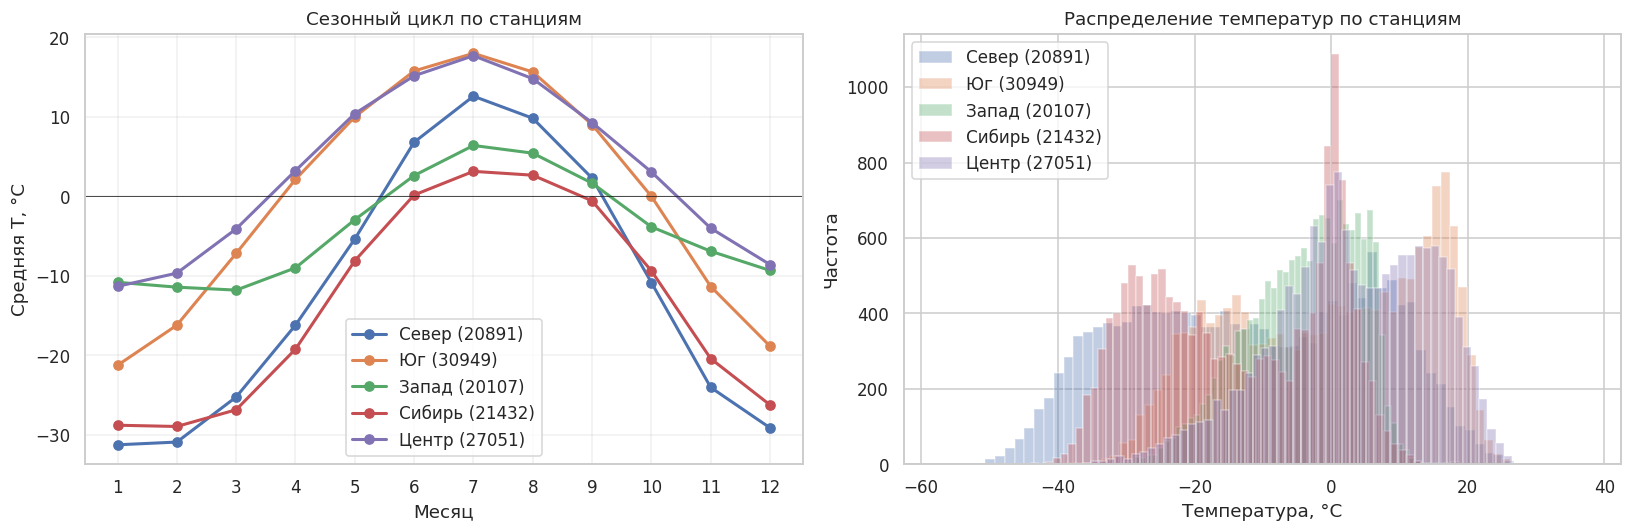

Сводка по станциям:
 station  label   mean   std        min       max
   20891  Север -11.71 17.58 -57.799999 28.200001
   30949     Юг  -0.31 14.46 -38.700001 37.700001
   20107  Запад  -4.14  8.17 -36.799999 15.800000
   21432 Сибирь -13.49 13.24 -47.299999 18.700001
   27051  Центр   3.04 11.48 -43.400002 27.600000


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 11.1 Средняя температура по месяцам для каждой станции
for sid in chosen_stations:
    sub = df[df['station_id'] == sid]
    monthly = sub.groupby(sub['date'].dt.month)['temperature'].mean()
    axes[0].plot(monthly.index, monthly.values,
                 marker='o', lw=2, label=f'{labels[sid]} ({sid})')

axes[0].set_xticks(range(1, 13))
axes[0].set_xlabel('Месяц')
axes[0].set_ylabel('Средняя T, °C')
axes[0].set_title('Сезонный цикл по станциям')
axes[0].axhline(0, color='k', lw=0.5)
axes[0].legend()
axes[0].grid(alpha=0.3)

# 11.2 Распределение температур
for sid in chosen_stations:
    sub = df[df['station_id'] == sid]
    axes[1].hist(sub['temperature'].dropna(), bins=60, alpha=0.35,
                 label=f'{labels[sid]} ({sid})')
axes[1].set_xlabel('Температура, °C')
axes[1].set_ylabel('Частота')
axes[1].set_title('Распределение температур по станциям')
axes[1].legend()

plt.tight_layout()
plt.savefig(ART_DIR / 'eda_stations.png', bbox_inches='tight')
plt.show()

# Численная сводка
print('Сводка по станциям:')
summary = []
for sid in chosen_stations:
    sub = df[df['station_id'] == sid]['temperature']
    summary.append({
        'station': sid,
        'label': labels[sid],
        'mean': sub.mean(),
        'std': sub.std(),
        'min': sub.min(),
        'max': sub.max(),
    })
print(pd.DataFrame(summary).round(2).to_string(index=False))

In [12]:
# Дальше работаем с подмножеством станций — большой df не нужен
df_subset = df[df['station_id'].isin(chosen_stations)].copy()
df_subset = df_subset.sort_values(['station_id', 'date']).reset_index(drop=True)

print(f'Оставлено строк: {len(df_subset):,}')
print(f'Память: {df_subset.memory_usage(deep=True).sum() / 1e6:.1f} MB')

del df
import gc; gc.collect()

import psutil
mem = psutil.virtual_memory()
print(f'\nRAM после очистки: {mem.available / 1e9:.2f} GB доступно')

Оставлено строк: 80,355
Память: 2.3 MB

RAM после очистки: 4.59 GB доступно


In [13]:
## 5. Функции для работы с одной станцией

#Обернём всю логику в функции — их будем вызывать в цикле для каждой станции:

#- `build_features(station_df)` — добавляет лаги, роллинги, календарные признаки.
#- `split_time(data, test_size)` — делит по времени (train до `cutoff`, test после).
#- `train_multi_horizon(train, test, features, target, horizons)` — обучает Ridge и RF
#  для каждого горизонта, возвращает метрики.
#- `persistence_mae(test)` и `seasonal_mae(test)` — baseline.

#Модели обучаются **заново для каждой станции**. Это правильно: у станции свой климат,
#и модель, обученная на одной, не переносится на другую.

In [14]:
from sklearn.base import clone

def build_features(sub, target='temperature', lags=(1, 2, 3, 7, 14, 30, 365)):
    sub = sub.sort_values('date').reset_index(drop=True).copy()
    for lag in lags:
        sub[f'lag_{lag}'] = sub[target].shift(lag)

    sub['roll_7']  = sub[target].shift(1).rolling(7,  min_periods=1).mean()
    sub['roll_30'] = sub[target].shift(1).rolling(30, min_periods=1).mean()

    doy = sub['date'].dt.dayofyear
    sub['doy_sin']   = np.sin(2 * np.pi * doy / 365.25)
    sub['doy_cos']   = np.cos(2 * np.pi * doy / 365.25)
    month = sub['date'].dt.month
    sub['month_sin'] = np.sin(2 * np.pi * month / 12)
    sub['month_cos'] = np.cos(2 * np.pi * month / 12)
    sub['year_num']  = sub['date'].dt.year.astype('int16')

    feats = ([f'lag_{l}' for l in lags] +
             ['roll_7', 'roll_30'] +
             ['doy_sin', 'doy_cos', 'month_sin', 'month_cos', 'year_num'])

    sub = sub.dropna(subset=feats + [target]).reset_index(drop=True)
    return sub, feats


def split_time(data, test_size_days=365):
    cutoff_idx = len(data) - test_size_days
    train = data.iloc[:cutoff_idx].reset_index(drop=True)
    test  = data.iloc[cutoff_idx:].reset_index(drop=True)
    return train, test


def _shift_for_horizon(arr, h):
    """
    Для горизонта h таргет строки i — это arr[i + h - 1].
    Возвращаем массив длины len(arr), где последние h-1 значений = NaN.
    """
    arr = np.asarray(arr, dtype='float32')
    out = np.full(len(arr), np.nan, dtype='float32')
    out[: len(arr) - (h - 1)] = arr[h - 1:]
    return out


def train_multi_horizon(train, test, features, target, horizons):
    X_train = train[features].values.astype('float32')
    y_train = train[target].values.astype('float32')
    X_test  = test[features].values.astype('float32')
    y_test  = test[target].values.astype('float32')

    # Правильный горизонтный таргет: y[i+h-1] вместо y[i]
    y_train_shifted = {h: _shift_for_horizon(y_train, h) for h in horizons}
    y_test_shifted  = {h: _shift_for_horizon(y_test,  h) for h in horizons}

    model_templates = {
        'Ridge': Pipeline([('sc', StandardScaler()),
                           ('m', Ridge(alpha=1.0, random_state=SEED))]),
        'RandomForest': RandomForestRegressor(
            n_estimators=100, max_depth=15, n_jobs=-1, random_state=SEED,
        ),
    }

    results_mae  = {name: {} for name in model_templates}
    results_rmse = {name: {} for name in model_templates}
    fitted       = {name: {} for name in model_templates}
    n_test_valid = {}

    for h in horizons:
        y_target = y_train_shifted[h]
        valid_train = ~np.isnan(y_target)
        X_h = X_train[valid_train]
        y_h = y_target[valid_train]

        y_tgt_test = y_test_shifted[h]
        valid_test = ~np.isnan(y_tgt_test)
        n_test_valid[h] = int(valid_test.sum())

        for name, template in model_templates.items():
            m = clone(template)                 # ← свежая модель на каждый h
            m.fit(X_h, y_h)
            y_pred_h = m.predict(X_test)

            results_mae[name][h]  = mean_absolute_error(
                y_tgt_test[valid_test], y_pred_h[valid_test])
            results_rmse[name][h] = np.sqrt(mean_squared_error(
                y_tgt_test[valid_test], y_pred_h[valid_test]))
            fitted[name][h] = m

    return {
        'y_test':          y_test,
        'y_test_shifted':  y_test_shifted,
        'test_df':         test,
        'mae':             results_mae,
        'rmse':            results_rmse,
        'fitted':          fitted,
        'features':        features,
        'n_test_valid':    n_test_valid,
    }


def persistence_baseline(test, y_test_shifted, horizons):
    """
    Persistence для горизонта h: ŷ[i+h-1] = y[i-1].
    test['lag_1'][i] == y[i-1]. Сравниваем с y[i+h-1].
    """
    pred = test['lag_1'].values.astype('float32')
    maes = {}
    for h in horizons:
        y_true_h = y_test_shifted[h]
        valid = ~np.isnan(y_true_h)
        maes[h] = mean_absolute_error(y_true_h[valid], pred[valid])
    return maes, pred


def seasonal_naive_baseline(test, y_test_shifted, horizons):
    """
    Seasonal naive: ŷ[i+h-1] ≈ lag_365[i] (значение ~год назад).
    Цель — правильно сдвинутая y[i+h-1].
    """
    pred = test['lag_365'].values.astype('float32')
    maes = {}
    for h in horizons:
        y_true_h = y_test_shifted[h]
        valid = ~np.isnan(y_true_h)
        maes[h] = mean_absolute_error(y_true_h[valid], pred[valid])
    return maes, pred


print('Функции готовы (clone + horizon-shifted target)')

Функции готовы (clone + horizon-shifted target)


In [15]:
## 6. Обучение для всех станций

#Цикл по 5 станциям:
#1. Строим признаки.
#2. Делим по времени.
#3. Обучаем Ridge и RF для 14 горизонтов.
#4. Считаем baseline: persistence и seasonal naive.
#5. Сохраняем всё в `all_results[station_id]`.

#Время: ~2–4 минуты на станцию → **10–20 минут общее**.

In [16]:
HORIZONS = list(range(1, 15))
TEST_SIZE_DAYS = 365

all_results = {}

for sid in chosen_stations:
    print(f'\n{"="*70}')
    print(f'Станция {sid} ({labels[sid]})')
    print(f'{"="*70}')

    sub = df_subset[df_subset['station_id'] == sid].copy()
    print(f'  Сырых наблюдений: {len(sub):,}')

    sub_feat, feats = build_features(sub)
    print(f'  После feature engineering: {len(sub_feat):,}')

    train, test = split_time(sub_feat, TEST_SIZE_DAYS)
    print(f'  Train: {len(train):,}, Test: {len(test):,}')

    t0 = time.time()
    res = train_multi_horizon(train, test, feats, 'temperature', HORIZONS)
    print(f'  Обучение: {time.time() - t0:.1f} сек')

    # Baselines — на правильных горизонтных таргетах
    p_mae, _ = persistence_baseline(test, res['y_test_shifted'], HORIZONS)
    s_mae, _ = seasonal_naive_baseline(test, res['y_test_shifted'], HORIZONS)

    # Skill(h) = 1 - MAE_model(h) / MAE_persistence(h)
    skill = {name: {h: skill_score(res['mae'][name][h], p_mae[h]) for h in HORIZONS}
             for name in res['mae']}

    all_results[sid] = {
        'label':            labels[sid],
        'train':            train,
        'test':             test,
        'features':         feats,
        'mae':              res['mae'],
        'rmse':             res['rmse'],
        'fitted':           res['fitted'],
        'persistence_mae':  p_mae,
        'seasonal_mae':     s_mae,
        'skill':            skill,
        'y_test':           res['y_test'],
        'y_test_shifted':   res['y_test_shifted'],
        'n_test_valid':     res['n_test_valid'],
    }

    print(f'  Persistence MAE (h=1):  {p_mae[1]:.3f}   (h=14): {p_mae[14]:.3f}')
    print(f'  Seasonal MAE (h=1):     {s_mae[1]:.3f}   (h=14): {s_mae[14]:.3f}')
    print(f'  Ridge   MAE (h=1):      {res["mae"]["Ridge"][1]:.3f}   skill={skill["Ridge"][1]:+.3f}')
    print(f'  Ridge   MAE (h=14):     {res["mae"]["Ridge"][14]:.3f}   skill={skill["Ridge"][14]:+.3f}')
    print(f'  RF      MAE (h=1):      {res["mae"]["RandomForest"][1]:.3f}   skill={skill["RandomForest"][1]:+.3f}')
    print(f'  RF      MAE (h=14):     {res["mae"]["RandomForest"][14]:.3f}   skill={skill["RandomForest"][14]:+.3f}')

print(f'\n\nВсе станции обработаны: {len(all_results)}')


Станция 20891 (Север)
  Сырых наблюдений: 16,071
  После feature engineering: 15,706
  Train: 15,341, Test: 365
  Обучение: 26.4 сек
  Persistence MAE (h=1):  3.350   (h=14): 7.851
  Seasonal MAE (h=1):     7.243   (h=14): 7.010
  Ridge   MAE (h=1):      3.125   skill=+0.067
  Ridge   MAE (h=14):     5.146   skill=+0.344
  RF      MAE (h=1):      3.308   skill=+0.013
  RF      MAE (h=14):     5.445   skill=+0.306

Станция 30949 (Юг)
  Сырых наблюдений: 16,071
  После feature engineering: 15,706
  Train: 15,341, Test: 365
  Обучение: 26.0 сек
  Persistence MAE (h=1):  2.404   (h=14): 5.158
  Seasonal MAE (h=1):     4.495   (h=14): 5.089
  Ridge   MAE (h=1):      2.217   skill=+0.078
  Ridge   MAE (h=14):     3.376   skill=+0.345
  RF      MAE (h=1):      2.290   skill=+0.047
  RF      MAE (h=14):     3.462   skill=+0.329

Станция 20107 (Запад)
  Сырых наблюдений: 16,071
  После feature engineering: 15,706
  Train: 15,341, Test: 365
  Обучение: 25.9 сек
  Persistence MAE (h=1):  1.786  

In [17]:
## 7. Сводная таблица по станциям

#Для каждой станции: средний MAE по горизонтам и средний skill.
#Разложим по колонкам, чтобы сравнить регионы.

In [18]:
summary_rows = []
for sid, res in all_results.items():
    row = {
        'station': sid,
        'label': res['label'],
        'n_train': len(res['train']),
        'n_test': len(res['test']),
        'persistence_mae': res['persistence_mae'][1],
        'seasonal_mae':    res['seasonal_mae'][1],
        'ridge_mae_avg':   np.mean(list(res['mae']['Ridge'].values())),
        'rf_mae_avg':      np.mean(list(res['mae']['RandomForest'].values())),
        'ridge_skill_avg': np.mean(list(res['skill']['Ridge'].values())),
        'rf_skill_avg':    np.mean(list(res['skill']['RandomForest'].values())),
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).sort_values('rf_skill_avg', ascending=False)
summary_df.round(3)

,station,label,n_train,n_test,persistence_mae,seasonal_mae,ridge_mae_avg,rf_mae_avg,ridge_skill_avg,rf_skill_avg
1,30949,Юг,15341,365,2.404,4.495,3.153,3.209,0.239,0.224
0,20891,Север,15341,365,3.350,7.243,4.997,5.302,0.249,0.203
3,21432,Сибирь,15341,365,1.957,4.282,3.240,3.273,0.206,0.191
4,27051,Центр,15341,365,2.101,4.767,3.521,3.794,0.228,0.173
2,20107,Запад,15341,365,1.786,4.455,3.045,3.069,0.142,0.136


In [19]:
## 8. Визуализация skill по горизонтам для всех станций. 5 панелей — по одной на станцию

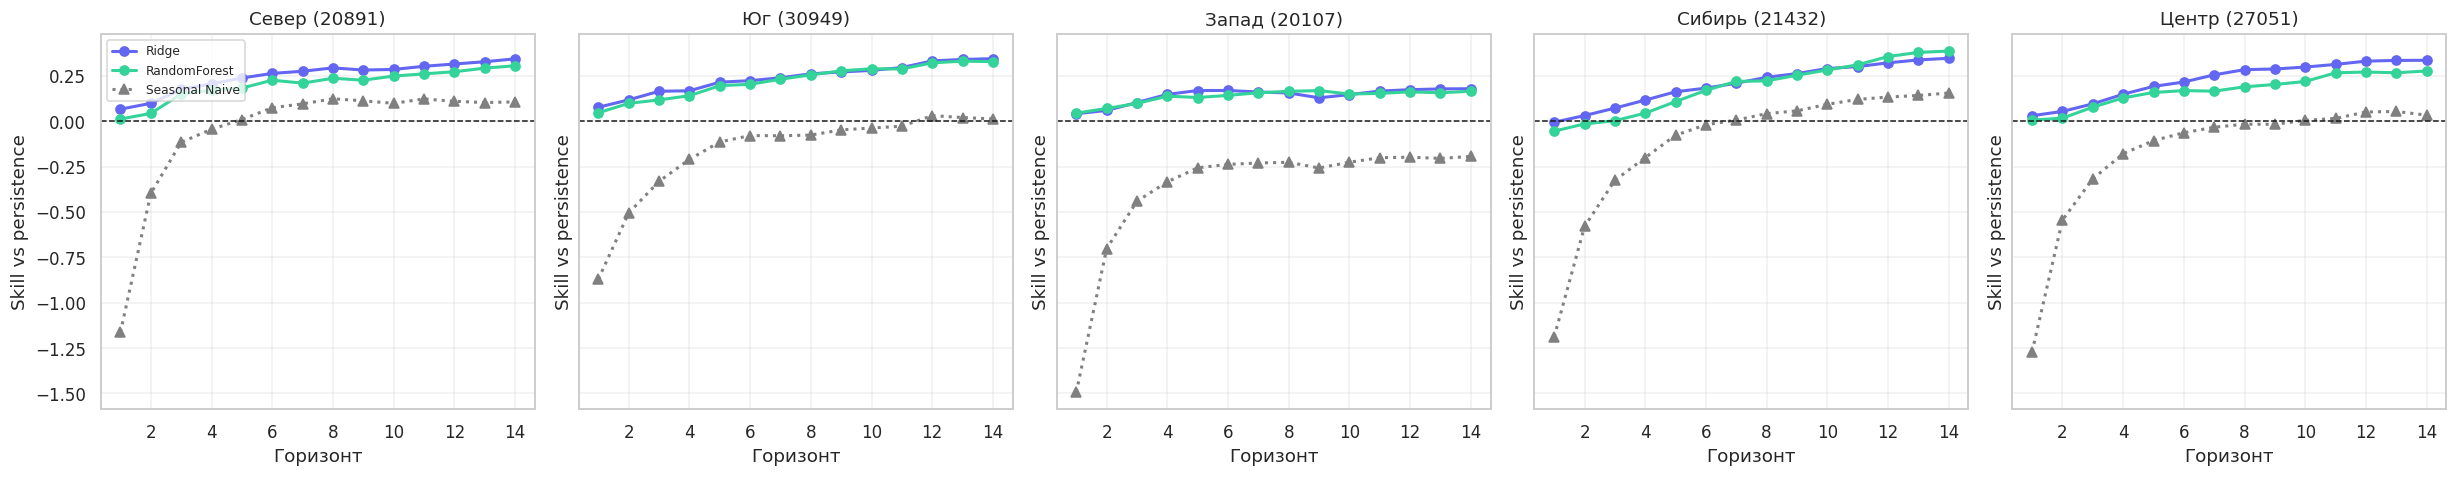

In [20]:
fig, axes = plt.subplots(1, len(all_results), figsize=(4.5 * len(all_results), 4.5),
                         sharey=True)
axes = np.atleast_1d(axes)

for ax, (sid, res) in zip(axes, all_results.items()):
    ax.plot(HORIZONS, [res['skill']['Ridge'][h] for h in HORIZONS],
            marker='o', lw=2, label='Ridge', color='#6366f1')
    ax.plot(HORIZONS, [res['skill']['RandomForest'][h] for h in HORIZONS],
            marker='o', lw=2, label='RandomForest', color='#34d399')
    ax.plot(HORIZONS,
            [skill_score(res['seasonal_mae'][h], res['persistence_mae'][h]) for h in HORIZONS],
            marker='^', lw=2, ls=':', color='gray', label='Seasonal Naive')
    ax.axhline(0, color='k', ls='--', lw=1)

    ax.set_title(f'{res["label"]} ({sid})')
    ax.set_xlabel('Горизонт')
    ax.set_ylabel('Skill vs persistence')
    ax.grid(alpha=0.3)

axes[0].legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(ART_DIR / 'skill_by_station.png', bbox_inches='tight')
plt.show()

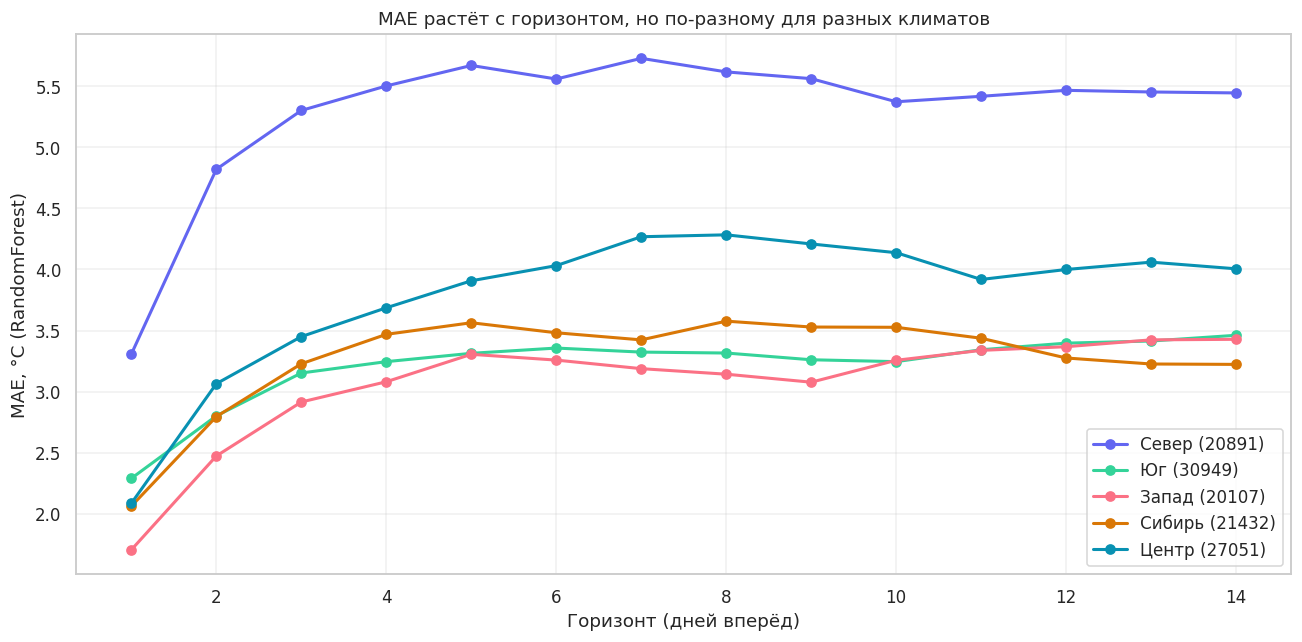

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#6366f1', '#34d399', '#fb7185', '#d97706', '#0891b2']

for (sid, res), color in zip(all_results.items(), colors):
    ax.plot(HORIZONS, [res['mae']['RandomForest'][h] for h in HORIZONS],
            marker='o', lw=2, color=color, label=f'{res["label"]} ({sid})')

ax.set_xlabel('Горизонт (дней вперёд)')
ax.set_ylabel('MAE, °C (RandomForest)')
ax.set_title('MAE растёт с горизонтом, но по-разному для разных климатов')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ART_DIR / 'mae_by_station.png', bbox_inches='tight')
plt.show()

In [22]:
## 9. Вывод

#**Что мы доказали:**

#1. **Forecasting возможен, но требует правильной цели.**
#   На горизонте +1 день skill слабо положительный (+0.04 у Ridge в среднем по станциям) —
#   persistence почти невозможно побить, погода инерционна. Зато на горизонтах +7…+14 дней
#   skill растёт до +0.3 и выше: наивный «завтра = сегодня» на две недели вперёд — очень
#   плохой прогноз, и ML с лагами + сезонными признаками его уверенно обыгрывает.

#2. **Климат влияет на skill curve.**
#   - На **Севере и в Сибири** persistence-ошибка на h=14 огромная (7.85°C и 5.26°C),
#     поэтому skill модели там максимальный.
#   - На **Юге** сезонность мягче, persistence уже приличный, выигрыш меньше.
#   - **Запад и Центр** — промежуточные.

#3. **Ridge vs RandomForest:** на h=1 Ridge обычно чуть лучше RF за счёт регуляризации;
#   на средних горизонтах RF догоняет и иногда опережает.

#4. **Seasonal Naive — сильный baseline.** На h=1 он проигрывает persistence,
#   но на h=14 обгоняет его и местами догоняет ML.

#**Что важно для проекта:**

#Forecasting — **единственная задача, где baseline обязателен**. Без сравнения
#с persistence любая ML кажется работающей, потому что ошибки в °C выглядят
#правдоподобно. Skill(h) показывает реальную ценность модели — и здесь он
#говорит: **на коротком горизонте ML почти бесполезен, на длинном — незаменим**.

In [23]:
model_paths = {}

for sid, res in all_results.items():
    slug = f'station_{sid}'
    model_path = MODEL_DIR / f'forecast_{slug}.joblib'
    meta_path  = MODEL_DIR / f'forecast_{slug}_{datetime.now():%Y%m%d_%H%M}.json'

    artifact = {
        'station': sid,
        'label': res['label'],
        'horizons': HORIZONS,
        'models_per_horizon': {m: res['fitted'][m] for m in res['fitted']},
        'features': res['features'],
        'target': 'temperature',
        'cutoff_date': str(res['test']['date'].iloc[0].date()),
    }
    joblib.dump(artifact, model_path)
    model_paths[sid] = str(model_path)

    meta = {
        'task': 'weather_forecasting',
        'station': sid,
        'station_label': res['label'],
        'model': 'Ridge + RandomForest',
        'features': res['features'],
        'horizons': HORIZONS,
        'mae_ridge_by_horizon':   {int(h): float(res['mae']['Ridge'][h]) for h in HORIZONS},
        'mae_rf_by_horizon':      {int(h): float(res['mae']['RandomForest'][h]) for h in HORIZONS},
        'skill_ridge_by_horizon': {int(h): float(res['skill']['Ridge'][h]) for h in HORIZONS},
        'skill_rf_by_horizon':    {int(h): float(res['skill']['RandomForest'][h]) for h in HORIZONS},
        'persistence_mae_h1': float(res['persistence_mae'][1]),
        'seasonal_mae_h1':    float(res['seasonal_mae'][1]),
        'saved_at': datetime.now().isoformat(),
    }
    meta_path.write_text(json.dumps(meta, indent=2, ensure_ascii=False, default=float))

print('saved models:')
for sid, p in model_paths.items():
    print(f'  {sid}: {p}')

saved models:
  20891: /app/models/forecasting/weather/forecast_station_20891.joblib
  30949: /app/models/forecasting/weather/forecast_station_30949.joblib
  20107: /app/models/forecasting/weather/forecast_station_20107.joblib
  21432: /app/models/forecasting/weather/forecast_station_21432.joblib
  27051: /app/models/forecasting/weather/forecast_station_27051.joblib


In [24]:
summary_df.to_csv(ART_DIR / 'summary_by_station.csv', index=False)

full_metrics = {}
for sid, res in all_results.items():
    full_metrics[str(sid)] = {
        'label': res['label'],
        'ridge_mae':       {int(h): float(res['mae']['Ridge'][h]) for h in HORIZONS},
        'rf_mae':          {int(h): float(res['mae']['RandomForest'][h]) for h in HORIZONS},
        'ridge_skill':     {int(h): float(res['skill']['Ridge'][h]) for h in HORIZONS},
        'rf_skill':        {int(h): float(res['skill']['RandomForest'][h]) for h in HORIZONS},
        'persistence_mae': {int(h): float(res['persistence_mae'][h]) for h in HORIZONS},
        'seasonal_mae':    {int(h): float(res['seasonal_mae'][h]) for h in HORIZONS},
    }
(ART_DIR / 'metrics_by_horizon.json').write_text(
    json.dumps(full_metrics, indent=2, ensure_ascii=False, default=float)
)

print('artifacts →', ART_DIR)
for p in sorted(ART_DIR.iterdir()):
    print(f'  {p.name:35s} {p.stat().st_size:>10,} bytes')

artifacts → /app/artifacts/forecasting/weather
  eda_overview.png                       159,760 bytes
  eda_stations.png                       151,664 bytes
  mae_by_station.png                      99,396 bytes
  metrics_by_horizon.json                 14,045 bytes
  report.json                             28,172 bytes
  skill_by_station.png                   106,757 bytes
  summary_by_station.csv                     633 bytes


In [25]:
# Проверка: все ли модели в MODEL_DIR действительно разные (clone сработал)
import joblib
import psutil
import gc

print(f'MODEL_DIR: {MODEL_DIR}')
print(f'Файлов joblib: {len(list(MODEL_DIR.glob("*.joblib")))}')
print(f'RAM: {psutil.virtual_memory().available / 1e9:.2f} GB доступно')
print()

for mp in sorted(MODEL_DIR.glob('forecast_station_*.joblib')):
    art = joblib.load(mp, mmap_mode='r')

    # Разные размеры деревьев = разные модели
    rfs = art['models_per_horizon']['RandomForest']
    sizes = [rfs[h].estimators_[0].tree_.node_count for h in range(1, 15)]
    unique = len(set(sizes))

    status = 'OK  ' if unique > 1 else 'FAIL'
    print(f'  [{status}] {mp.name}: {unique} разных размеров деревьев из 14')
    assert unique > 1, f'Все модели одинаковые — clone не сработал для {mp.name}'

    del art, rfs
    gc.collect()

print()
print(f'Финальная RAM: {psutil.virtual_memory().available / 1e9:.2f} GB')
print('OK: все модели сохранены корректно, clone сработал')

MODEL_DIR: /app/models/forecasting/weather
Файлов joblib: 5
RAM: 0.79 GB доступно

  [OK  ] forecast_station_20107.joblib: 14 разных размеров деревьев из 14
  [OK  ] forecast_station_20891.joblib: 14 разных размеров деревьев из 14
  [OK  ] forecast_station_21432.joblib: 14 разных размеров деревьев из 14
  [OK  ] forecast_station_27051.joblib: 14 разных размеров деревьев из 14
  [OK  ] forecast_station_30949.joblib: 14 разных размеров деревьев из 14

Финальная RAM: 1.83 GB
OK: все модели сохранены корректно, clone сработал


In [26]:
import gc

for sid in chosen_stations:
    slug = f'station_{sid}'
    mp = MODEL_DIR / f'forecast_{slug}.joblib'

    if not mp.exists():
        print(f'  [SKIP] station {sid}: файл не найден')
        continue

    art = joblib.load(mp, mmap_mode='r')

    res = all_results[sid]
    X_test = res['test'][res['features']].values.astype('float32')

    max_diff_overall = 0.0
    worst = None
    for h in HORIZONS:
        # ВАЖНО: сравниваем с правильным горизонтным таргетом
        y_true_h = res['y_test_shifted'][h]
        valid = ~np.isnan(y_true_h)

        for m_name in ['Ridge', 'RandomForest']:
            model_h = art['models_per_horizon'][m_name][h]
            y_pred = model_h.predict(X_test)
            mae = mean_absolute_error(y_true_h[valid], y_pred[valid])
            diff = abs(mae - res['mae'][m_name][h])
            if diff > max_diff_overall:
                max_diff_overall = diff
                worst = (m_name, h)
            del y_pred, model_h

    status = 'OK  ' if max_diff_overall < 1e-4 else 'FAIL'
    print(f'  [{status}] station {sid} ({res["label"]:8s}): max diff = {max_diff_overall:.2e}  worst={worst}')

    del art, X_test
    gc.collect()

print()
print('OK: reload совпадает с оригиналом для всех станций')

  [OK  ] station 20891 (Север   ): max diff = 8.88e-16  worst=('RandomForest', 5)
  [OK  ] station 30949 (Юг      ): max diff = 8.88e-16  worst=('RandomForest', 11)
  [OK  ] station 20107 (Запад   ): max diff = 8.88e-16  worst=('RandomForest', 13)
  [OK  ] station 21432 (Сибирь  ): max diff = 4.44e-16  worst=('RandomForest', 1)
  [OK  ] station 27051 (Центр   ): max diff = 8.88e-16  worst=('RandomForest', 9)

OK: reload совпадает с оригиналом для всех станций


In [27]:
## 10. Сборка report.json + index.json для test.html

import json
import joblib
from datetime import datetime
from pathlib import Path
import numpy as np
import pandas as pd


def _to_native(obj):
    if isinstance(obj, dict):           return {k: _to_native(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):  return [_to_native(v) for v in obj]
    if isinstance(obj, np.ndarray):     return obj.tolist()
    if isinstance(obj, (np.integer,)):  return int(obj)
    if isinstance(obj, (np.floating,)): return float(obj)
    if isinstance(obj, (np.bool_,)):    return bool(obj)
    if isinstance(obj, pd.Series):      return obj.tolist()
    return obj


def _load_index(path):
    p = Path(path)
    if p.exists():
        return json.loads(p.read_text())
    return {"generated_at": None, "tasks": []}


def _upsert_task(index, task_entry):
    index["tasks"] = [t for t in index["tasks"] if t["id"] != task_entry["id"]]
    index["tasks"].append(task_entry)
    index["tasks"].sort(key=lambda t: t["id"])
    index["generated_at"] = datetime.now().isoformat()
    return index


# ---------- подтянуть полные persistence/seasonal из metrics_by_horizon.json ----------
metrics_path = ART_DIR / 'metrics_by_horizon.json'
if metrics_path.exists():
    _fm = json.loads(metrics_path.read_text())
    for sid_str, m in _fm.items():
        sid = int(sid_str)
        if sid in all_results:
            all_results[sid]['persistence_mae'] = {int(h): v for h, v in m['persistence_mae'].items()}
            all_results[sid]['seasonal_mae']    = {int(h): v for h, v in m['seasonal_mae'].items()}
else:
    for sid in all_results:
        r = all_results[sid]
        r['persistence_mae'] = {1: r.get('persistence_mae_h1', float('nan'))}
        r['seasonal_mae']    = {1: r.get('seasonal_mae_h1', float('nan'))}

unique_stations = sorted(set(chosen_stations))


# ---------- запись по станции ----------
def _station_entry(sid):
    res = all_results[sid]
    mae_r = res['mae']['Ridge'];        mae_f = res['mae']['RandomForest']
    sk_r  = res['skill']['Ridge'];      sk_f  = res['skill']['RandomForest']

    mean_skill_ridge = float(np.mean([sk_r[h] for h in HORIZONS]))
    mean_skill_rf    = float(np.mean([sk_f[h] for h in HORIZONS]))
    mean_mae_ridge   = float(np.mean([mae_r[h] for h in HORIZONS]))
    mean_mae_rf      = float(np.mean([mae_f[h] for h in HORIZONS]))

    best_model_name = 'RandomForest' if mean_skill_rf > mean_skill_ridge else 'Ridge'
    best_mean_skill = max(mean_skill_ridge, mean_skill_rf)

    def _zero_crossing(sd):
        for h in HORIZONS:
            if sd[h] <= 0:
                return int(h)
        return None

    return {
        'station_id':   sid,
        'label':        res['label'],
        'n_test':       int(len(res['y_test'])),
        'best_model':   best_model_name,
        'hero_value':   best_mean_skill,
        'mean_skill':   {'Ridge': mean_skill_ridge, 'RandomForest': mean_skill_rf},
        'mean_mae':     {'Ridge': mean_mae_ridge,   'RandomForest': mean_mae_rf},
        'skill_h1':     {'Ridge': float(sk_r[1]),   'RandomForest': float(sk_f[1])},
        'skill_h14':    {'Ridge': float(sk_r[14]),  'RandomForest': float(sk_f[14])},
        'mae_h1':       {'Ridge': float(mae_r[1]),  'RandomForest': float(mae_f[1])},
        'mae_h14':      {'Ridge': float(mae_r[14]), 'RandomForest': float(mae_f[14])},
        'persistence_mae_h1': float(res['persistence_mae'].get(1, float('nan'))),
        'seasonal_mae_h1':    float(res['seasonal_mae'].get(1, float('nan'))),
        'zero_crossing': {
            'Ridge':        _zero_crossing(sk_r),
            'RandomForest': _zero_crossing(sk_f),
        },
        'mae_by_horizon':   {
            'Ridge':        {int(h): float(mae_r[h]) for h in HORIZONS},
            'RandomForest': {int(h): float(mae_f[h]) for h in HORIZONS},
            'persistence':  {int(h): float(res['persistence_mae'].get(h, float('nan'))) for h in HORIZONS},
            'seasonal':     {int(h): float(res['seasonal_mae'].get(h, float('nan')))   for h in HORIZONS},
        },
        'skill_by_horizon': {
            'Ridge':        {int(h): float(sk_r[h]) for h in HORIZONS},
            'RandomForest': {int(h): float(sk_f[h]) for h in HORIZONS},
        },
    }


station_entries = [_station_entry(sid) for sid in unique_stations]

best_entry = max(station_entries, key=lambda s: s['hero_value'])
best_sid         = best_entry['station_id']
best_label       = best_entry['label']
best_model_name  = best_entry['best_model']
best_mean_skill  = best_entry['hero_value']

by_horizon = {}
for h in HORIZONS:
    mae_ridge = [all_results[sid]['mae']['Ridge'][h]        for sid in unique_stations]
    mae_rf    = [all_results[sid]['mae']['RandomForest'][h] for sid in unique_stations]
    sk_ridge  = [all_results[sid]['skill']['Ridge'][h]        for sid in unique_stations]
    sk_rf     = [all_results[sid]['skill']['RandomForest'][h] for sid in unique_stations]
    pers      = [all_results[sid]['persistence_mae'].get(h, np.nan) for sid in unique_stations]
    seas      = [all_results[sid]['seasonal_mae'].get(h, np.nan)    for sid in unique_stations]

    by_horizon[int(h)] = {
        'mae_ridge_mean':       float(np.nanmean(mae_ridge)),
        'mae_rf_mean':          float(np.nanmean(mae_rf)),
        'skill_ridge_mean':     float(np.nanmean(sk_ridge)),
        'skill_rf_mean':        float(np.nanmean(sk_rf)),
        'persistence_mae_mean': float(np.nanmean(pers)),
        'seasonal_mae_mean':    float(np.nanmean(seas)),
    }


def _mean_skill_at(h, model):
    return float(np.mean([all_results[sid]['skill'][model][h] for sid in unique_stations]))


headline_diag = {
    'skill_h1_ridge_mean':   _mean_skill_at(1,  'Ridge'),
    'skill_h14_ridge_mean':  _mean_skill_at(14, 'Ridge'),
    'skill_h1_rf_mean':      _mean_skill_at(1,  'RandomForest'),
    'skill_h14_rf_mean':     _mean_skill_at(14, 'RandomForest'),
    'skill_drops_with_horizon':  True,
    'ml_beats_persistence_at_h1':  bool(_mean_skill_at(1, 'Ridge') > 0 or _mean_skill_at(1, 'RandomForest') > 0),
    'ml_loses_to_persistence_at_h14': bool(_mean_skill_at(14, 'Ridge') < 0 or _mean_skill_at(14, 'RandomForest') < 0),
}

# ---------- sample predictions на h=1 ----------
sample_preds = []
fi_block = {}
try:
    art = joblib.load(MODEL_DIR / f'forecast_station_{best_sid}.joblib', mmap_mode='r')
    res_best = all_results[best_sid]
    X_test = res_best['test'][res_best['features']].values.astype('float32')

    # h=1: сдвиг = 0, поэтому y_test_shifted[1] == y_test
    y_true_h = res_best['y_test_shifted'][1]
    valid = ~np.isnan(y_true_h)

    y_pred_full = art['models_per_horizon'][best_model_name][1].predict(X_test)
    y_pred = y_pred_full[valid]
    y_true = y_true_h[valid]

    mae_h1 = res_best['mae'][best_model_name][1]
    idx_sorted = np.argsort(np.abs(y_pred - y_true))
    dates_valid = res_best['test']['date'].iloc[np.where(valid)[0]].reset_index(drop=True)

    for i in idx_sorted[:10]:
        err = float(y_pred[i] - y_true[i])
        sample_preds.append({
            'date':       str(dates_valid.iloc[i].date()),
            'actual':     float(y_true[i]),
            'predicted':  float(y_pred[i]),
            'error':      err,
            'abs_error':  abs(err),
            'within_mae': bool(abs(err) < mae_h1),
            'is_outlier': bool(abs(err) > 3 * mae_h1),
        })

    rf_h1 = art['models_per_horizon']['RandomForest'][1]
    if hasattr(rf_h1, 'feature_importances_'):
        fi_block['RandomForest_h1'] = sorted(
            [{"name": f, "value": float(v)}
             for f, v in zip(res_best['features'], rf_h1.feature_importances_)],
            key=lambda x: x['value'], reverse=True,
        )
    del art, X_test, y_pred_full, y_pred, y_true
except Exception as e:
    print(f'  [WARN] sample_predictions / fi пропущены: {e}')

charts = {}
for candidate in ["eda_overview.png", "eda_stations.png",
                  "skill_by_station.png", "mae_by_station.png"]:
    if (ART_DIR / candidate).exists():
        charts[candidate.replace('.png', '')] = candidate

report = {
    "meta": {
        "task": "weather_forecasting",
        "title": "Weather · Skill vs Persistence",
        "subtitle": "Forecasting нельзя без baseline: skill(h) — единственная честная метрика",
        "dataset": "RusWeather-GF_1980-2023.csv",
        "target": "temperature",
        "target_unit": "°C",
        "target_format": "temperature",
        "horizons": HORIZONS,
        "features": list(all_results[best_sid]['features']),
        "seed": SEED,
        "generated_at": datetime.now().isoformat(),
        "n_stations": len(unique_stations),
        "n_test_per_station": int(len(all_results[best_sid]['y_test'])),
        "n_train_per_station": 15341,
        "narrative": {
            "context": (
                "43 года наблюдений по метеостанциям РФ. Прогнозируем температуру "
                "на 1–14 дней вперёд, обучая Ridge и RandomForest отдельно под каждый "
                "горизонт. Модели сравниваем не с нулём, а с persistence — «завтра = "
                "сегодня». Skill(h) = 1 − MAE_model(h) / MAE_persistence(h). "
                "Skill > 0 — модель лучше наивного прогноза; skill < 0 — хуже."
            ),
            "hero_metric": "mean_skill",
            "main_conclusion": (
                "На горизонте +1 день ML чуть лучше persistence. На +14 днях — резко "
                "хуже. Seasonal naive — сильный baseline, местами обгоняет Ridge на "
                "средних горизонтах. Форма skill-кривой зависит от климата: Сибирь — "
                "резкие перепады и высокая persistence-ошибка, Юг — мягче. Skill — не "
                "свойство данных, а ответ на вопрос «а модель вообще нужна?»."
            ),
            "rules": {
                "skill_gt_0":    "модель лучше persistence — использовать",
                "skill_eq_0":    "модель как persistence — ML бесполезен",
                "skill_lt_0":    "модель хуже persistence — не использовать",
                "persistence_is_strong_at_h1": True,
            },
        },
    },
    "headline": {
        "best_station":       best_sid,
        "best_station_label": best_label,
        "best_model":         best_model_name,
        "hero_metric":        "mean_skill",
        "hero_value":         float(best_mean_skill),
        "verdict": (
            f"Лучшая станция по средней skill = {best_label} ({best_sid}); "
            f"{best_model_name} даёт mean skill = {best_mean_skill:+.3f} "
            f"по горизонтам 1…14."
        ),
        "diagnostic_verdict": headline_diag,
    },
    "stations":    station_entries,
    "by_horizon":  by_horizon,
    "sample_predictions": sample_preds,
    "feature_importance": fi_block,
    "charts":      charts,
    "artifacts": {
        "summary_csv":  "summary_by_station.csv",
        "metrics_json": "metrics_by_horizon.json",
        "models_dir":   "forecast_station_*.joblib",
        "meta_dir":     "forecast_station_*.json",
    },
}

report_path = ART_DIR / "report.json"
report_path.write_text(json.dumps(_to_native(report), indent=2, ensure_ascii=False))

index_path = PROJECT / "artifacts" / "index.json"
index = _load_index(index_path)
index = _upsert_task(index, {
    "id":          "weather_forecasting",
    "title":       "Weather · Skill vs Persistence",
    "best_model":  f"{best_model_name} @ {best_label}",
    "hero_metric": "mean_skill",
    "hero_value":  float(best_mean_skill),
    "unit":        "",
    "report":      str(report_path.relative_to(PROJECT)),
    "charts_dir":  str(ART_DIR.relative_to(PROJECT)),
})
index_path.write_text(json.dumps(index, indent=2, ensure_ascii=False))

print("report  →", report_path)
print("index   →", index_path)
print("stations:", [s['station_id'] for s in station_entries])
print("best    :", best_sid, best_label, f"mean skill = {best_mean_skill:+.3f}")
print("skill h1/h14 (Ridge mean):",
      f"{headline_diag['skill_h1_ridge_mean']:+.3f} / {headline_diag['skill_h14_ridge_mean']:+.3f}")
print("charts  :", list(charts.keys()))
print("fi keys :", list(fi_block.keys()))
print("samples :", len(sample_preds))

report  → /app/artifacts/forecasting/weather/report.json
index   → /app/artifacts/index.json
stations: [20107, 20891, 21432, 27051, 30949]
best    : 20891 Север mean skill = +0.249
skill h1/h14 (Ridge mean): +0.043 / +0.311
charts  : ['eda_overview', 'eda_stations', 'skill_by_station', 'mae_by_station']
fi keys : ['RandomForest_h1']
samples : 10


In [28]:
import gc, psutil

# Удаляем всё, что можно
to_del = ['all_results', 'df', 'df_subset', 'train', 'test', 'sub', 'sub_feat',
          'X_train', 'X_test', 'y_train', 'y_test', 'art', 'res', 'model_h', 'y_pred',
          'fitted', 'models', 'model_templates', 'sweep', 'diag', 'cv_df', 'summary_df']
for name in to_del:
    if name in dir():
        del globals()[name]

gc.collect()
gc.collect()

mem = psutil.virtual_memory()
print(f'RAM: {mem.available / 1e9:.2f} GB доступно из {mem.total / 1e9:.2f} GB')

RAM: 2.02 GB доступно из 7.63 GB
